In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sys
import matplotlib.patches as mpatches
import matplotlib as mpl

# ---- Adobe-friendly fonts (must be set BEFORE plotting) ----
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42



df1 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/group-housed/fed-fed/speed_over_time.csv')
df1['Condition'] = 'GH Fed-Fed'

df2 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/group-housed/fed-starved/speed_over_time.csv')
df2['Condition'] = 'GH Fed-Starved'

df3 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/group-housed/starved-starved/speed_over_time.csv')
df3['Condition'] = 'GH Starved-Starved'


df4 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/socially-isolated/fed-fed/speed_over_time.csv')
df4['Condition'] = 'SI Fed-Fed'

df5 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/socially-isolated/fed-starved/speed_over_time.csv')
df5['Condition'] = 'SI Fed-Starved'

df6 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/socially-isolated/starved-starved/speed_over_time.csv')
df6['Condition'] = 'SI Starved-Starved'


df = pd.concat([df1, df2, df3, df4, df5, df6], ignore_index=True)




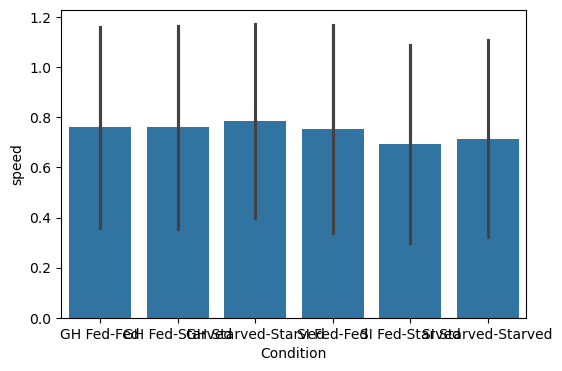

In [2]:

plt.figure(figsize=(6, 4))

sns.barplot(data=df, x='Condition', y='speed', errorbar='sd')

plt.show()

In [3]:
# bin speed into 600 second windows
condition_order = [
    'GH Fed-Fed', 'GH Fed-Starved', 'GH Starved-Starved',
    'SI Fed-Fed', 'SI Fed-Starved', 'SI Starved-Starved'
]

palette = {
    'GH Fed-Fed': '#2F6F4E',
    'GH Fed-Starved': '#7A5BA6',
    'GH Starved-Starved': '#B84E4E',
    'SI Fed-Fed': '#8BC49A',
    'SI Fed-Starved': '#C3A6D8',
    'SI Starved-Starved': '#E39A93',
}

df['Housing'] = np.where(df['Condition'].str.contains('GH'), 'GH', 'SI')
df['Feeding'] = df['Condition'].str.replace('GH ', '', regex=False).str.replace('SI ', '', regex=False)
df['time_bin'] = ((df['time'] - 1) // 600) * 600 + 1
df['time_bin_label'] = df['time_bin'].astype(int).astype(str) + '-' + (df['time_bin'] + 599).astype(int).astype(str)

speed_bins = df.groupby(['Condition', 'Housing', 'Feeding', 'file', 'time_bin', 'time_bin_label']).agg(
    average_speed=('speed', 'mean')
).reset_index()

speed_bins.head()


,Condition,Housing,Feeding,file,time_bin,time_bin_label,average_speed
0,GH Fed-Fed,GH,Fed-Fed,2026-04-28_12-19-24_td11.tracks.feather,1,1-600,0.606707
1,GH Fed-Fed,GH,Fed-Fed,2026-04-28_12-19-24_td11.tracks.feather,601,601-1200,0.626501
2,GH Fed-Fed,GH,Fed-Fed,2026-04-28_12-19-24_td11.tracks.feather,1201,1201-1800,0.775738
3,GH Fed-Fed,GH,Fed-Fed,2026-04-28_12-19-24_td11.tracks.feather,1801,1801-2400,0.773099
4,GH Fed-Fed,GH,Fed-Fed,2026-04-28_12-19-24_td11.tracks.feather,2401,2401-3000,0.826858


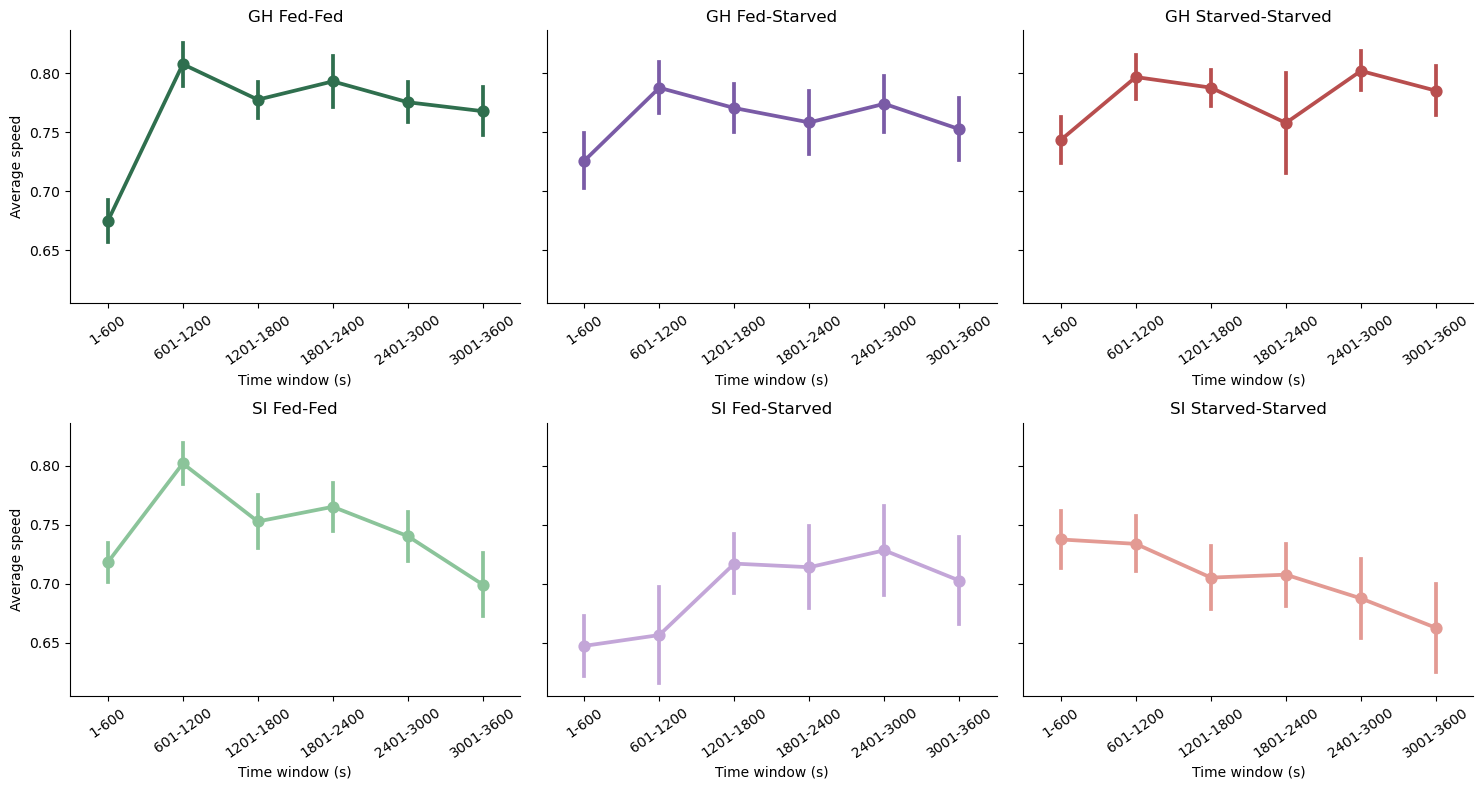

In [4]:
# each condition separately
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=True)
axes = axes.flatten()

for ax, condition in zip(axes, condition_order):
    sub = speed_bins[speed_bins['Condition'] == condition]
    sns.pointplot(
        data=sub,
        x='time_bin_label',
        y='average_speed',
        color=palette[condition],
        errorbar='se',
        ax=ax,
    )
    ax.set_title(condition)
    ax.set_xlabel('Time window (s)')
    ax.set_ylabel('Average speed')
    ax.tick_params(axis='x', rotation=35)
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()


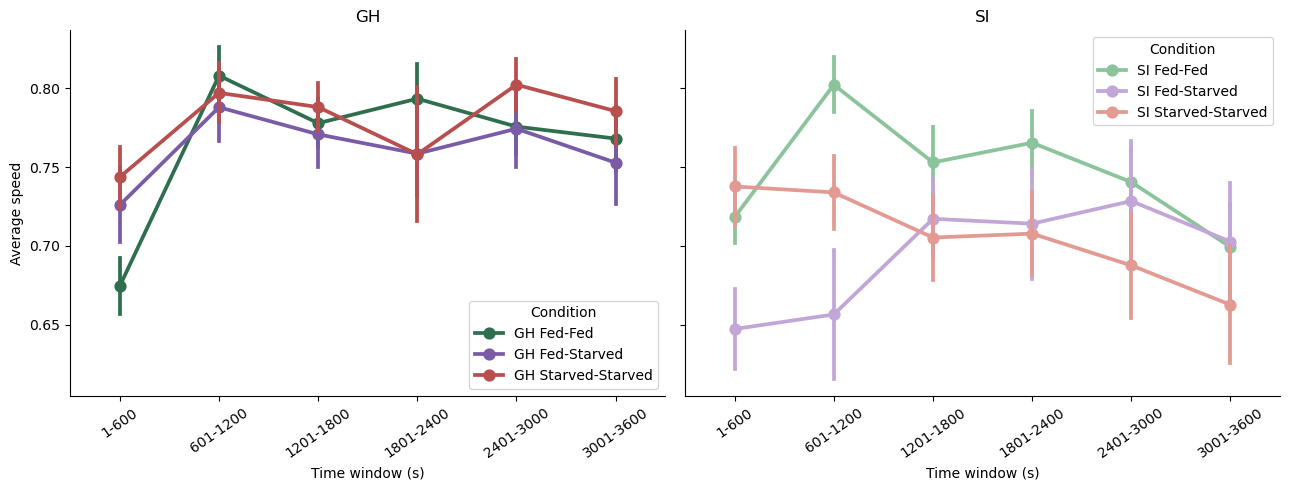

In [5]:
# group-housed on one side, socially-isolated on the other
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for ax, housing in zip(axes, ['GH', 'SI']):
    sub = speed_bins[speed_bins['Housing'] == housing]
    order = [c for c in condition_order if c.startswith(housing)]
    sns.pointplot(
        data=sub,
        x='time_bin_label',
        y='average_speed',
        hue='Condition',
        hue_order=order,
        palette=palette,
        errorbar='se',
        ax=ax,
    )
    ax.set_title(housing)
    ax.set_xlabel('Time window (s)')
    ax.set_ylabel('Average speed')
    ax.tick_params(axis='x', rotation=35)
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()
